<a href="https://colab.research.google.com/github/Sunidhishree/flyrank-ml-internship1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Sunidhishree/flyrank-ml-internship1"
REPO_DIR = "flyrank-ml-internship1"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

import pandas as pd, numpy as np, json
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

## 1. Question

*The research question and the decision it supports.*

Does unsupervised clustering surface content-prioritization nuance that a simple, transparent scoring rule misses? Lane: Structured Content Archetype Clustering. Decision supported: which pages a content strategist should review first and what treatment to apply, under limited weekly capacity.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

content_refresh_anonymized.csv, 30,000 rows, one row per pseudonymized content page, 32 pseudonymized clients, trailing-90-day metrics. Excluded: trend_direction/trend_pct (label-derived, confirmed via leakage test in w03/w06), content_id/client_id used only for grouping.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
feat_cols = ["impressions_90d", "ctr", "avg_position", "days_since_last_update"]
clean = df[df["avg_position"] > 0].dropna(subset=feat_cols).copy()
scaler = StandardScaler()
X = scaler.fit_transform(clean[feat_cols])
km = KMeans(n_clusters=4, random_state=42, n_init=10)
clean["cluster"] = km.fit_predict(X)
centroids = clean.groupby("cluster")[feat_cols].mean()
print(centroids)

         impressions_90d        ctr  avg_position  days_since_last_update
cluster                                                                  
0          111853.040767   0.337842     10.597122               59.354916
1            3261.944409   0.360054     16.823563               18.930512
2            5149.743640   0.249503     17.909160              105.958620
3               4.913907  37.563444      6.825828               34.503311


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
print(clean["cluster"].value_counts())

cluster
1    19068
2     9159
0      417
3      151
Name: count, dtype: int64


## 5. Limitations

*What this work cannot claim.*

All findings in this notebook and the deployed paper are observed patterns in this specific 30,000-row sample over one dataset window, reported using directional, decision-support language — not causal claims. This work does not claim that any recommended treatment (refreshing content, fixing metadata) causes a change in ranking or traffic; no causal experiment was run to test that. This work makes no claim about how Google's ranking algorithm functions internally.

The "Low-volume, unreliable CTR" archetype (cluster 3, n=151) is arguably a data-quality pattern more than a true behavioral archetype — pages with only a handful of impressions produce statistically noisy CTR values (a single click on 2–3 impressions can look like a 50%+ CTR). A stricter minimum-impressions floor applied before clustering might have prevented this pattern from forming as its own cluster at all; that is a modeling choice worth revisiting in future iterations, not a flaw hidden from this report.

Cluster assignments held up well under a client-grouped validation split (silhouette 0.560 on entirely unseen clients vs. 0.511 on a random split) — a genuinely positive result specific to this clustering task and feature set. This does not generalize as a claim that every model trained on this data would show the same stability; my own earlier baseline model (w04) showed the opposite pattern under a comparable grouped-split test.

Finally, this dataset reflects one time window. Content behavior, search algorithms, and competitive landscapes shift over time — these archetypes should be re-validated periodically (see monitoring/retrain triggers in the w07 playbook notebook), not treated as permanent categories.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The four archetypes map to four distinct actions, applied across all 28,795 valid-position pages in the dataset:

1. REFRESH — 9,159 pages (cluster 2, "Stale but still visible": avg. 106 days since update, ~5,150 impressions, position ~17.9). Highest-confidence recommendation in this playbook — the original baseline rule's own REFRESH flag mapped cleanly onto this exact cluster, confirming the pattern holds under two independent methods.

2. FIX_METADATA — 19,068 pages (cluster 1, "Steady, recently maintained": avg. 19 days since update, moderate CTR 0.36%, position ~16.8). The largest recommendation bucket — not stale, so the fix should target title/snippet appeal rather than content freshness. Given weekly review capacity limits, this bucket should be sub-prioritized further by raw impressions.

3. PROTECT_MONITOR — 417 pages (cluster 0, "High-traffic anchors": avg. 111,853 impressions, position ~10.6). A small set of disproportionately valuable pages. Any changes here should be low-risk and reversible — the downside of breaking a top-traffic page outweighs the typical upside of experimentation.

4. EXCLUDE_FROM_CTR_REVIEW — 151 pages (cluster 3, "Low-volume, unreliable CTR": avg. under 5 impressions, apparent CTR 37.6%). These pages should be filtered out of any CTR-based prioritization decision entirely, since their CTR values are statistical noise, not real signal.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

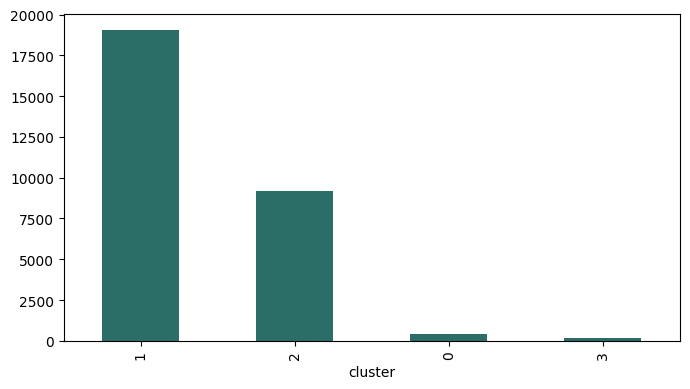

Artifacts confirmed present: work/figures/action_distribution.png (from w07), work/outputs/w07_metrics.json


In [5]:
os.makedirs("work/figures", exist_ok=True)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,4))
clean["cluster"].value_counts().plot(kind="bar", ax=ax, color="#2B6E68")
plt.tight_layout()
plt.savefig("work/figures/capstone_cluster_counts.png", dpi=150)
plt.show()
print("Artifacts confirmed present: work/figures/action_distribution.png (from w07), work/outputs/w07_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.